<a href="https://colab.research.google.com/github/asomanibernard191-arch/Syntecxhub_Credit_Card_Fraud_Detection/blob/main/Syntecxhub_Credit_Card_Fraud_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from imblearn.over_sampling import SMOTE

# Setting plot style
sns.set_theme(style="whitegrid")

# Downloading the Credit Card Fraud Detection dataset automatically
path = kagglehub.dataset_download("mlg-ulb/creditcardfraud")

# Loading the dataset
df = pd.read_csv(f"{path}/creditcard.csv")

# Displaying dataset summary
print(f"Dataset Shape: {df.shape}")
df.head()

Using Colab cache for faster access to the 'creditcardfraud' dataset.
Dataset Shape: (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


Class Counts:
 Class
0    284315
1       492
Name: count, dtype: int64

Fraud Percentage: 0.173%


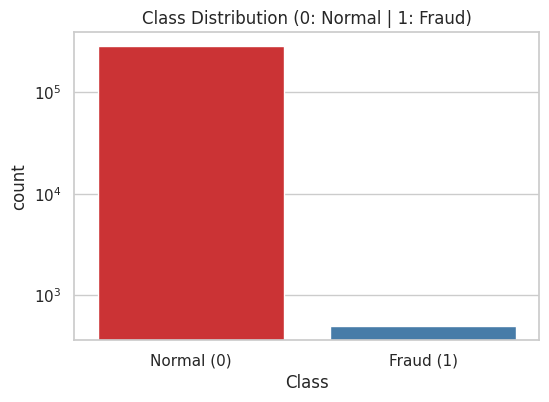

In [17]:
# Checking class distribution (0 = Normal, 1 = Fraud)
class_counts = df['Class'].value_counts()
print("Class Counts:\n", class_counts)

# Calculating fraud percentage
fraud_percentage = (class_counts[1] / len(df)) * 100
print(f"\nFraud Percentage: {fraud_percentage:.3f}%")

# Plotting the class distribution
plt.figure(figsize=(6, 4))
sns.countplot(x='Class', hue='Class', data=df, palette='Set1', legend=False)
plt.title('Class Distribution (0: Normal | 1: Fraud)')
plt.xticks([0, 1], ['Normal (0)', 'Fraud (1)'])
plt.yscale('log') # Log scale makes the tiny fraud bar visible
plt.show()


In [18]:
# Separating features and target
X = df.drop(columns=['Class'])
y =  df['Class']

# Scaling 'Time' and 'Amount' features
scaler = StandardScaler()
X[['Time', 'Amount']] = scaler.fit_transform(X[['Time', 'Amount']])

# 80/20 Train-Test Split with stratification
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Applying SMOTE to the training set only
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print("--- Class Distribution Before SMOTE ---")
print(y_train.value_counts())

print("\n--- Class Distribution After SMOTE ---")
print(y_train_resampled.value_counts())

--- Class Distribution Before SMOTE ---
Class
0    227451
1       394
Name: count, dtype: int64

--- Class Distribution After SMOTE ---
Class
0    227451
1    227451
Name: count, dtype: int64


---nClassification Report ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.85      0.84      0.84        98

    accuracy                           1.00     56962
   macro avg       0.92      0.92      0.92     56962
weighted avg       1.00      1.00      1.00     56962

ROC-AUC Score: 0.9731


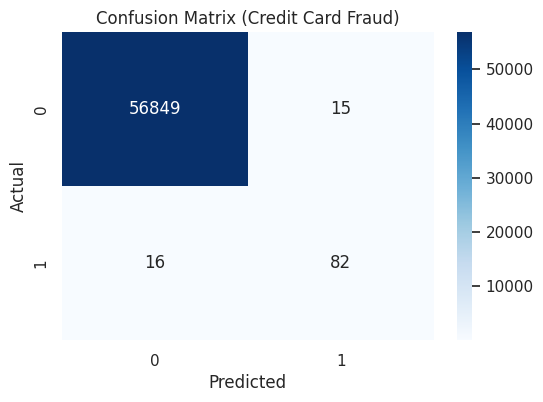

In [20]:
# Train Random Forest on resampled training data
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=1)
rf_model.fit(X_train_resampled, y_train_resampled)

# Predicting on unseen test data
y_pred = rf_model.predict(X_test)
y_pred_proba = rf_model.predict_proba(X_test)[:, 1]

# Displaying evaluation metrics
print("---nClassification Report ---")
print(classification_report(y_test, y_pred))

print(f"ROC-AUC Score: {roc_auc_score(y_test, y_pred_proba):.4f}")


# Plotting Confusion Matrix
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d',cmap='Blues')
plt.title('Confusion Matrix (Credit Card Fraud)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()